In [3]:
# Step 1: Connect Google Drive so we can access our dataset
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive connected!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive connected!


In [4]:
# Step 2: Import all the tools we need
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models

print("All libraries imported!")

All libraries imported!


In [ ]:
# Step 3: Load our handwritten alphabet images from Drive
dataset_path = '/content/drive/MyDrive/alphabet_project/dataset'
IMG_SIZE = 28
X = []
y = []
alphabet_labels = sorted([
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
])
print("Letters found:", alphabet_labels)
print("Total classes:", len(alphabet_labels))
for label_index, letter in enumerate(alphabet_labels):
    folder_path = os.path.join(dataset_path, letter)
    for image_file in os.listdir(folder_path):
        image_path = os.path.join(folder_path, image_file)
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
img = img / 255.0
X.append(img)
y.append(label_index)
print(f"\nTotal images loaded: {len(X)}")
print(f"Total labels: {len(y)}")

Letters found: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Total classes: 26

Total images loaded: 1
Total labels: 1


In [ ]:
# Step 4: Increase our dataset using data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(rotation_range=10, width_shift_range=0.1,  height_shift_range=0.1, zoom_range=0.1 )
X_aug = []
y_aug = []
AUGMENT_COUNT = 10
for i in range(len(X)):
    img = X[i].reshape(1, IMG_SIZE, IMG_SIZE, 1)
    X_aug.append(X[i])
    y_aug.append(y[i])
    count = 0
    for batch in datagen.flow(img, batch_size=1):
        aug_img = batch[0].reshape(IMG_SIZE, IMG_SIZE)
        X_aug.append(aug_img)
        y_aug.append(y[i])
        count += 1
        if count >= AUGMENT_COUNT:
            break
print(f"Total images after augmentation: {len(X_aug)}")
print(f"Per letter (approx): {len(X_aug) // len(alphabet_labels)}")

Total images after augmentation: 11
Per letter (approx): 0


In [ ]:
# Step 5: Convert lists to arrays and split into train & test
X_final = np.array(X_aug).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
y_final = np.array(y_aug)
# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split( X_final, y_final, test_size=0.2, random_state=42 )
print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print(f"Image shape      : {X_train[0].shape}")

Training samples : 8
Testing samples  : 3
Image shape      : (28, 28, 1)


IndexError: index 16 is out of bounds for axis 0 with size 8

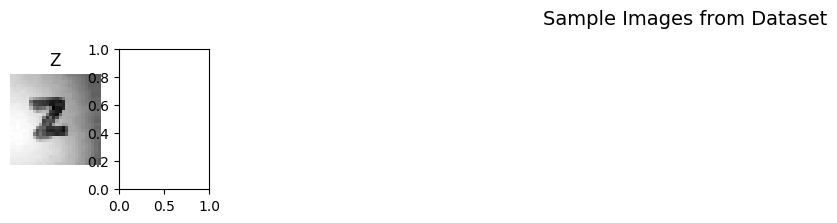

In [ ]:
# Step 6: Display a few sample images from our dataset
plt.figure(figsize=(18, 4))
plt.suptitle("Sample Images from Dataset", fontsize=14)
for i in range(13):
    plt.subplot(2, 13, i + 1)
    plt.imshow(X_train[i * 16].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title(alphabet_labels[y_train[i * 16]])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Step 7: Build our Convolutional Neural Network (CNN)
num_classes = len(alphabet_labels)  # 26 letters
model = models.Sequential([ layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)), layers.MaxPooling2D(2, 2), layers.Conv2D(64, (3, 3), activation='relu'), layers.MaxPooling2D(2, 2), layers.Flatten(), layers.Dense(128, activation='relu'), layers.Dropout(0.3),    layers.Dense(num_classes, activation='softmax') ])
model.compile( optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

In [ ]:
history = model.fit( X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1 )
prediction = model.predict(X_test)
print("\nWhat the model saw (Top 5):")
top5 = np.argsort(prediction[0])[::-1][:5]
for rank, idx in enumerate(top5):
    bar = "█" * int(prediction[0][idx] * 30)
    print(f"  {rank+1}. {alphabet_labels[idx]}  {bar}  {prediction[0][idx]*100:.1f}%")
print("\nTraining complete!")

In [ ]:
# Step 9: Plot training graphs to evaluate model performance
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Step 10: Evaluate model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")
y_pred = np.argmax(model.predict(X_test), axis=1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=alphabet_labels))

In [ ]:
# Step 11: Show some test images with predicted vs actual labels
plt.figure(figsize=(18, 4))
plt.suptitle("Sample Predictions", fontsize=14)
for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(X_test[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    pred  = alphabet_labels[y_pred[i]]
    actual = alphabet_labels[y_test[i]]
    color = 'green' if pred == actual else 'red'
    plt.title(f"P:{pred}\nA:{actual}", color=color, fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Step 12: Save the trained model to Google Drive
save_path = '/content/drive/MyDrive/alphabet_project/alphabet_model.keras'
model.save(save_path)
print("Model saved successfully!")
print("Location:", save_path)

In [ ]:
# Step 13: Upload a new handwritten letter and predict it

from google.colab import files
print("Upload your handwritten letter photo...")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
img = cv2.imdecode(np.frombuffer(uploaded[filename], np.uint8), cv2.IMREAD_GRAYSCALE)
if np.mean(img) < 127:
    img = cv2.bitwise_not(img)
img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
img_input   = (img_resized / 255.0).reshape(1, IMG_SIZE, IMG_SIZE, 1)
prediction      = model.predict(img_input, verbose=0)
predicted_index = np.argmax(prediction)
predicted_label = alphabet_labels[predicted_index]
confidence      = np.max(prediction) * 100
plt.figure(figsize=(3, 3))
plt.imshow(img_resized, cmap='gray')
plt.title(f"Predicted: {predicted_label}\nConfidence: {confidence:.1f}%",
          fontsize=12, color='green')
plt.axis('off')
plt.show()
print(f"\nPredicted Letter : {predicted_label}")
print(f"Confidence       : {confidence:.2f}%")
print("\nTop 3 Guesses:")
top3 = np.argsort(prediction[0])[::-1][:3]
for rank, idx in enumerate(top3):
    print(f"  {rank+1}. {alphabet_labels[idx]}  →  {prediction[0][idx]*100:.1f}%")